In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import sys
sys.path.append('../series_alignment')
import series_alignment 
from scipy.interpolate import CubicSpline
import time
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple


In [4]:
OPTIM_KWARGS_APDIST = {"optim":"DP", "grid_dim":20, "lambda":0.0}
USE_LOG10_SAXS = False

## Load Experimental Data

In [5]:
path = '../Data/SAXS/Kinetics_Sq/'
filenames = sorted(os.listdir(path))

In [6]:
exp_saxs_data = []
for i in range(0, 10):
    data = np.load(path + filenames[i])
    exp_saxs_data.append(data)
print(f"Loaded {len(exp_saxs_data)} experimental SAXS datasets.")

Loaded 10 experimental SAXS datasets.


## Utilities

In [7]:
from scipy.signal import savgol_filter
from scipy.stats import shapiro
from scipy.signal import find_peaks
from scipy.integrate import trapezoid
import numpy as np
from scipy.interpolate import interp1d

def get_saxs_axis_labels():
    if USE_LOG10_SAXS:
        return r'$\log S(q)$', r'$ \log q \ (\AA^{-1})$'
    return r'$S(q)$', r'$q \ (\AA^{-1})$'

def apply_saxs_axis_format(ax):
    ylabel, xlabel = get_saxs_axis_labels()
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if not USE_LOG10_SAXS:
        ax.set_xscale('log')
        ax.set_yscale('log')

def quantify_saxs_smoothing(x_processed, y_processed_raw, y_processed_smooth):
    residual = y_processed_raw - y_processed_smooth

    rms_processed_residual = np.sqrt(np.mean(residual**2))

    if len(residual) > 1:
        residual_autocorr_lag1 = np.corrcoef(residual[:-1], residual[1:])[0, 1]
    else:
        residual_autocorr_lag1 = np.nan

    try:
        _, shapiro_p = shapiro(residual)
    except Exception:
        shapiro_p = np.nan

    if USE_LOG10_SAXS:
        q = 10**x_processed
        I_raw = 10**y_processed_raw
        I_smooth = 10**y_processed_smooth
    else:
        q = x_processed
        I_raw = y_processed_raw
        I_smooth = y_processed_smooth

    raw_peak_idx = np.argmax(I_raw)
    smooth_peak_idx = np.argmax(I_smooth)
    peak_shift = abs(q[raw_peak_idx] - q[smooth_peak_idx])

    invariant_raw = trapezoid((q**2) * I_raw, q)
    invariant_smooth = trapezoid((q**2) * I_smooth, q)
    invariant_rel_change = abs(invariant_smooth - invariant_raw) / invariant_raw

    return {
        "rms_log_residual": float(rms_processed_residual),
        "rms_processed_residual": float(rms_processed_residual),
        "residual_autocorr_lag1": float(residual_autocorr_lag1),
        "shapiro_p": float(shapiro_p),
        "peak_shift": float(peak_shift),
        "invariant_rel_change": float(invariant_rel_change),
    }

def smoothen_saxs_data(
    q,
    Iq,
    q_range=(0.004, 0.02),
    smooth=True,
    sg_window=7,
    sg_poly=2,
    return_metrics=False
):
    # Determine common q-range
    q_min = max(q.min(), q.min())
    q_max = min(q.max(), q.max())

    if q_range is not None:
        q_min = max(q_min, q_range[0])
        q_max = min(q_max, q_range[1])

    # Truncate experimental data
    mask_exp = (q >= q_min) & (q <= q_max)
    q_ref = q[mask_exp]
    Iq_ref = Iq[mask_exp]

    if USE_LOG10_SAXS:
        x = np.log10(q_ref)
        y = np.log10(Iq_ref)
    else:
        x = q_ref.copy()
        y = Iq_ref.copy()

    x_unique, unique_indices = np.unique(x, return_index=True)
    y_unique = y[unique_indices]

    if smooth and len(y_unique) >= sg_window:
        if sg_window % 2 == 0:
            sg_window += 1
        sg_window = min(sg_window, len(y_unique) if len(y_unique) % 2 == 1 else len(y_unique) - 1)
        if sg_window >= sg_poly + 2:
            y_unique = savgol_filter(y_unique, sg_window, sg_poly, mode="interp")

    if return_metrics:
        metrics = quantify_saxs_smoothing(x_unique, y[unique_indices], y_unique)
        return x_unique, y_unique, metrics
    return x_unique, y_unique

In [8]:
from IPython.display import display, HTML

def report_saxs_smoothing_metrics(metrics):
    rms_processed = metrics.get("rms_processed_residual", metrics.get("rms_log_residual", np.nan))
    if USE_LOG10_SAXS and np.isfinite(rms_processed):
        typical_linear_change_pct = (10**rms_processed - 1) * 100
    else:
        typical_linear_change_pct = np.nan

    thresholds = {
        "typical_linear_change_pct": (8.0, 20.0),
        "residual_autocorr_lag1": (0.15, 0.35),
        "shapiro_p": (0.05, 0.01),
        "peak_shift": (5e-4, 2e-3),
        "invariant_rel_change": (0.02, 0.08),
    }

    labels = {
        "typical_linear_change_pct": "Typical linear intensity change",
        "residual_autocorr_lag1": "Residual autocorr (lag 1)",
        "shapiro_p": "Shapiro p-value",
        "peak_shift": "Peak shift",
        "invariant_rel_change": "Invariant relative change",
    }

    notes = {
        "typical_linear_change_pct": "Typical percent change introduced by smoothing in linear intensity units.",
        "residual_autocorr_lag1": "Closer to 0 means removed signal looks more like noise.",
        "shapiro_p": "Higher is more consistent with normal residuals; secondary diagnostic only.",
        "peak_shift": "Smaller means smoothing preserved SAXS feature positions.",
        "invariant_rel_change": "Smaller means smoothing preserved integrated SAXS intensity.",
    }

    values = {
        "typical_linear_change_pct": typical_linear_change_pct,
        "residual_autocorr_lag1": metrics.get("residual_autocorr_lag1", np.nan),
        "shapiro_p": metrics.get("shapiro_p", np.nan),
        "peak_shift": metrics.get("peak_shift", np.nan),
        "invariant_rel_change": metrics.get("invariant_rel_change", np.nan),
    }

    def classify(name, value):
        if name == "typical_linear_change_pct" and not np.isfinite(value):
            return "N/A", "#e2e3e5", "#383d41"

        good, moderate = thresholds[name]

        if name == "shapiro_p":
            if value >= good:
                return "Good", "#d4edda", "#155724"
            if value >= moderate:
                return "Moderate", "#fff3cd", "#856404"
            return "Bad", "#f8d7da", "#721c24"

        value = abs(value)
        if value <= good:
            return "Good", "#d4edda", "#155724"
        if value <= moderate:
            return "Moderate", "#fff3cd", "#856404"
        return "Bad", "#f8d7da", "#721c24"

    def fmt(name, value):
        if name == "typical_linear_change_pct":
            return "N/A when USE_LOG10_SAXS=False" if not np.isfinite(value) else f"{value:.1f}%"
        if name == "shapiro_p":
            return f"{value:.3g}"
        if name == "residual_autocorr_lag1":
            return f"{value:.3f}"
        if name == "invariant_rel_change":
            return f"{value:.2%}"
        return f"{value:.4e}"

    rows = []
    for name in [
        "typical_linear_change_pct",
        "residual_autocorr_lag1",
        "shapiro_p",
        "peak_shift",
        "invariant_rel_change",
    ]:
        value = values[name]
        status, bg, fg = classify(name, value)
        rows.append(
            f"""
            <tr>
                <td style="padding:8px 12px; border:1px solid #ddd;">{labels[name]}</td>
                <td style="padding:8px 12px; border:1px solid #ddd; font-family:monospace;">{fmt(name, value)}</td>
                <td style="padding:8px 12px; border:1px solid #ddd; background:{bg}; color:{fg}; font-weight:600;">{status}</td>
                <td style="padding:8px 12px; border:1px solid #ddd;">{notes[name]}</td>
            </tr>
            """
        )

    html = f"""
    <div style="font-family:Arial, sans-serif; max-width:900px;">
        <h3 style="margin-bottom:10px;">SAXS Smoothing Report</h3>
        <table style="border-collapse:collapse; width:100%;">
            <thead>
                <tr style="background:#f2f2f2;">
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Metric</th>
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Value</th>
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Assessment</th>
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Interpretation</th>
                </tr>
            </thead>
            <tbody>
                {''.join(rows)}
            </tbody>
        </table>
    </div>
    """
    display(HTML(html))

## Plot Experimental Data

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

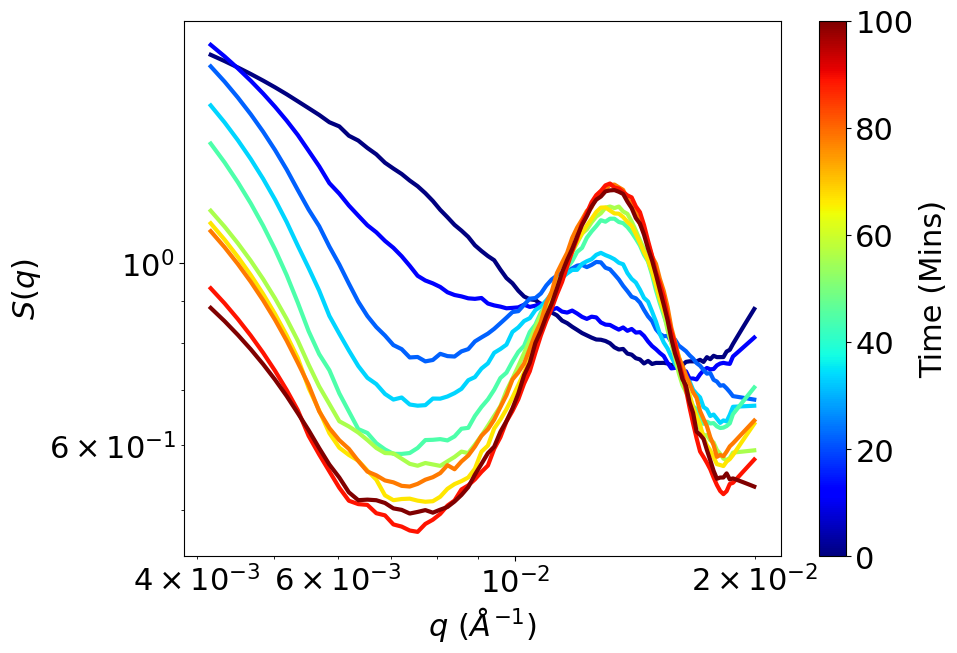

In [9]:
norm = colors.Normalize(vmin=0, vmax=100)
cmap = cm.jet
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
times = np.linspace(0,100, len(exp_saxs_data))
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(10,7))
for i in range(len(exp_saxs_data)):
    data = exp_saxs_data[i]
    q, Iq, metrics = smoothen_saxs_data(
        data[:,0], 
        data[:,1], 
        sg_window=15, 
        sg_poly=1, 
        return_metrics=True)
    ax.plot(q, Iq, linewidth = 3, color=sm.to_rgba(times[i]))
    apply_saxs_axis_format(ax)

cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Time (Mins)')
plt.tight_layout()
#plt.savefig('../Figures/exp_saxs.png', dpi=600, bbox_inches="tight")

In [10]:
report_saxs_smoothing_metrics(metrics)

Metric,Value,Assessment,Interpretation
Typical linear intensity change,N/A when USE_LOG10_SAXS=False,N/A,Typical percent change introduced by smoothing in linear intensity units.
Residual autocorr (lag 1),0.126,Good,Closer to 0 means removed signal looks more like noise.
Shapiro p-value,0.24,Good,Higher is more consistent with normal residuals; secondary diagnostic only.
Peak shift,6.8000e-04,Moderate,Smaller means smoothing preserved SAXS feature positions.
Invariant relative change,0.13%,Good,Smaller means smoothing preserved integrated SAXS intensity.


## Load Simulated Data

In [11]:
file_path = '../Data/Simulations/Simulation_File_8/Optimization_Results/Sample_0/Density_0.005_U_0_46.95_r0_2.25_n_1.0_m_20.89/scattering_data_mcdfm_sq/'
filenames = sorted(os.listdir(file_path))

sim_saxs_data = []
for i in range(len(filenames)):
    saxs_data = np.load(file_path + filenames[i])
    sim_saxs_data.append(saxs_data)

Metric,Value,Assessment,Interpretation
Typical linear intensity change,N/A when USE_LOG10_SAXS=False,N/A,Typical percent change introduced by smoothing in linear intensity units.
Residual autocorr (lag 1),0.614,Bad,Closer to 0 means removed signal looks more like noise.
Shapiro p-value,3.42e-10,Bad,Higher is more consistent with normal residuals; secondary diagnostic only.
Peak shift,0.0000e+00,Good,Smaller means smoothing preserved SAXS feature positions.
Invariant relative change,0.24%,Good,Smaller means smoothing preserved integrated SAXS intensity.


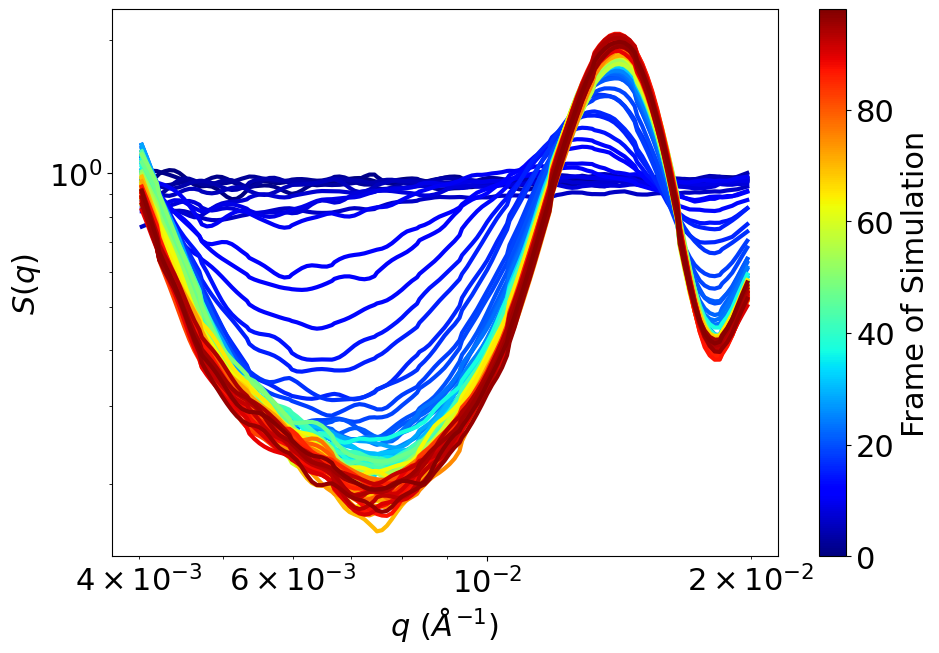

In [12]:
norm = colors.Normalize(vmin=0, vmax=len(sim_saxs_data))
cmap = cm.jet
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
times = np.linspace(0, len(sim_saxs_data)-1, len(sim_saxs_data))

fig, ax = plt.subplots(figsize=(10,7))
#for i in range(len(filenames)):
for i in range(len(sim_saxs_data)):
    data = sim_saxs_data[i]
    q, Iq, metrics = smoothen_saxs_data(
        data[:,0], 
        data[:,1],
        q_range=(0.004, 0.02), 
        sg_window=5, 
        sg_poly=1, 
        return_metrics=True,
    )
    ax.plot(q, Iq, linewidth = 3, color=sm.to_rgba(times[i]))
    apply_saxs_axis_format(ax)

cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Frame of Simulation')
plt.tight_layout()

report_saxs_smoothing_metrics(metrics)
#plt.savefig('../Figures/sim_saxs.png', dpi=600, bbox_inches="tight")

## Amplitude-Phase Distance

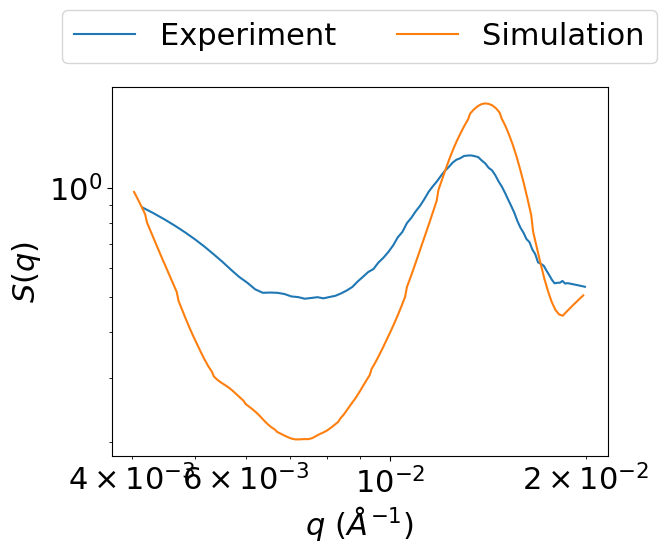

In [14]:
import numpy as np
import matplotlib.pyplot as plt 
from apdist.distances import AmplitudePhaseDistance as numpy_apdist 
from apdist.utils import plot_warping 
from apdist.geometry import SquareRootSlopeFramework as SRSF

sim_x = sim_saxs_data[41][:,0]
sim_y = sim_saxs_data[41][:,1]
sim_q, sim_Iq, _ = smoothen_saxs_data(sim_x, sim_y, sg_window=11, sg_poly=1, return_metrics=True)

expt_x = exp_saxs_data[9][:,0]
expt_y = exp_saxs_data[9][:,1]
expt_q, expt_Iq, _ = smoothen_saxs_data(expt_x, expt_y, sg_window=15, sg_poly=1, return_metrics=True)

fig, ax = plt.subplots()
ax.plot(expt_q, expt_Iq, label = 'Experiment')
ax.plot(sim_q, sim_Iq, label = 'Simulation')
apply_saxs_axis_format(ax)
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25))
plt.show()


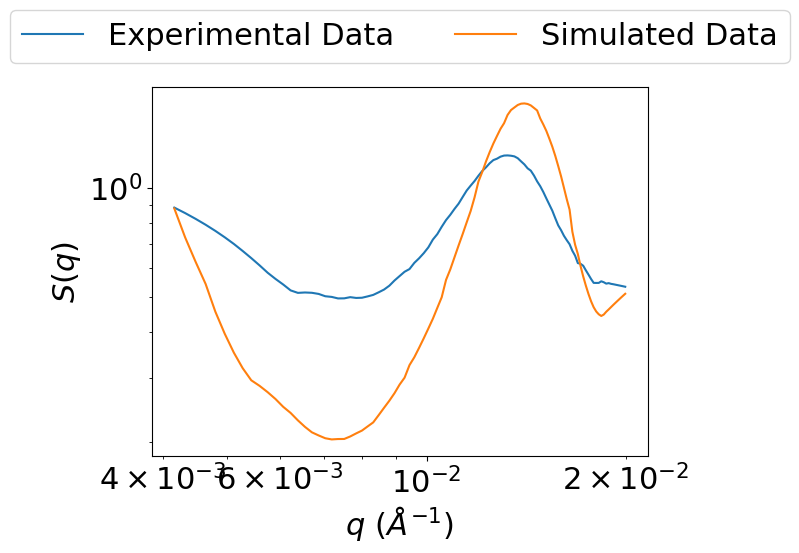

In [15]:
spline_expt = CubicSpline(expt_q, expt_Iq)
x_dense = np.linspace(expt_q.min(), expt_q.max(), 100)
x_dense_scaled = (x_dense-min(x_dense))/(max(x_dense)-min(x_dense))

y_dense_expt = spline_expt(x_dense)

spline_sim = CubicSpline(sim_q, sim_Iq)
y_dense_sim = spline_sim(x_dense)

fig, ax = plt.subplots()
ax.plot(x_dense, y_dense_expt, label='Experimental Data')
ax.plot(x_dense, y_dense_sim, label='Simulated Data')
apply_saxs_axis_format(ax)
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25))
plt.show()

In [16]:
def get_paired_curves(
    exp_data,
    sim_data,
    q_range=None,
):
    # Extract q and intensities
    q_exp = exp_data[:, 0]
    I_exp = exp_data[:, 1:]

    q_sim = sim_data[:, 0]
    I_sim = sim_data[:, 1:]

    # Determine common q-range
    q_min = max(q_exp.min(), q_sim.min())
    q_max = min(q_exp.max(), q_sim.max())

    if q_range is not None:
        q_min = max(q_min, q_range[0])
        q_max = min(q_max, q_range[1])

    # Truncate experimental data
    mask_exp = (q_exp >= q_min) & (q_exp <= q_max)
    q_ref = q_exp[mask_exp]
    I_exp = I_exp[mask_exp]

    # Truncate simulated data
    mask_sim = (q_sim >= q_min) & (q_sim <= q_max)
    q_sim_crop = q_sim[mask_sim]
    I_sim_crop = I_sim[mask_sim]

    if len(q_sim_crop) < 2:
        raise ValueError("Not enough simulated points for interpolation")

    # Interpolate simulated intensities onto experimental q-grid
    interp_func = interp1d(
        q_sim_crop,
        I_sim_crop,
        axis=0,
        kind="linear",
        bounds_error=False,
        fill_value="extrapolate",
    )
    I_sim_resampled = interp_func(q_ref)

    # Numerical safety
    eps = 1e-10
    I_exp = np.clip(I_exp, eps, None)
    I_sim_resampled = np.clip(I_sim_resampled, eps, None)
    q_ref_scaled = (q_ref - q_ref.min()) / (q_ref.max() - q_ref.min())

    return q_ref, q_ref_scaled, np.ravel(I_exp), np.ravel(I_sim_resampled)

def compare_pair(expt_id, sim_id):
    x_dense, x_dense_scaled, y_dense_expt, y_dense_sim = get_paired_curves(
        exp_data=exp_saxs_data[expt_id],
        sim_data=sim_saxs_data[sim_id],
        q_range=(0.004, 0.02)
    )
    _, y_dense_expt = smoothen_saxs_data(
        x_dense, y_dense_expt, sg_window=15, sg_poly=1
        )
    _, y_dense_sim = smoothen_saxs_data(
        x_dense, y_dense_sim, sg_window=5, sg_poly=1
        )
    print(f"Shapes of paired curves - x_dense: {x_dense.shape} ", 
          f"x_dense_scaled: {x_dense_scaled.shape} ", 
          f"y_dense_expt: {y_dense_expt.shape} ", 
          f"y_dense_sim: {y_dense_sim.shape}"
        )
    fig, ax = plt.subplots()
    ax.plot(x_dense, y_dense_expt, label='Experimental Data')
    ax.plot(x_dense, y_dense_sim, label='Simulated Data')
    apply_saxs_axis_format(ax)
    ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25))
    plt.show()

    y_ref = y_dense_expt.copy()/np.max(y_dense_expt)
    y_query = y_dense_sim.copy()/np.max(y_dense_sim)
    print(f"Reference curve min: {y_ref.min():.4f}, max: {y_ref.max():.4f}")
    print(f"Query curve min: {y_query.min():.4f}, max: {y_query.max():.4f}")
    a, p = numpy_apdist(x_dense_scaled, y_ref, y_query, **OPTIM_KWARGS_APDIST)
    print(f"(expt_id={expt_id}, sim_id={sim_id}) "
        f"Amplitude : {a:.4f}, Phase : {p:.4f}, Total : {np.abs(a + 1j*p).item():.4f}")

    srsf = SRSF(x_dense_scaled)
    q_query = srsf.to_srsf(y_query)
    q_ref = srsf.to_srsf(y_ref)
    gamma = srsf.get_gamma(q_ref, q_query, **OPTIM_KWARGS_APDIST)
    f_query_gamma = srsf.warp_f_gamma(y_query, gamma)
    plot_warping(x_dense_scaled, y_ref, y_query, f_query_gamma, gamma)
    plt.show()

Shapes of paired curves - x_dense: (94,)  x_dense_scaled: (94,)  y_dense_expt: (94,)  y_dense_sim: (94,)


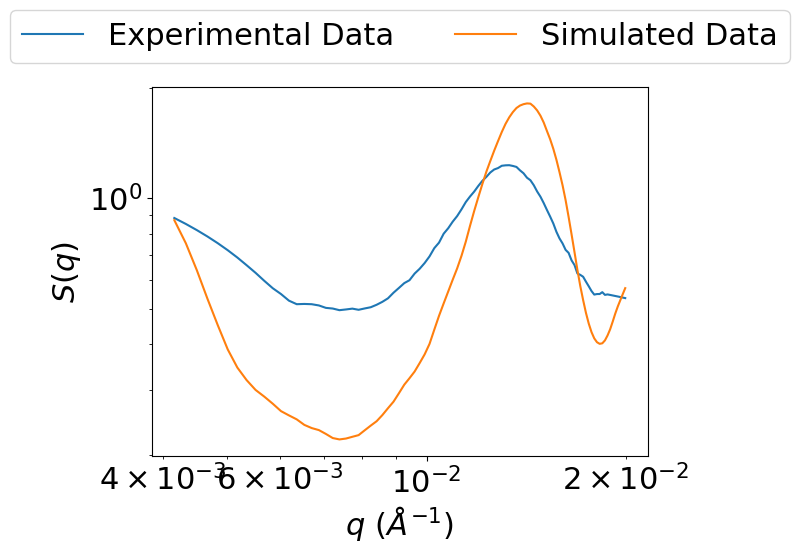

Reference curve min: 0.4029, max: 1.0000
Query curve min: 0.1216, max: 1.0000
(expt_id=9, sim_id=38) Amplitude : 0.4488, Phase : 0.3285, Total : 0.5562


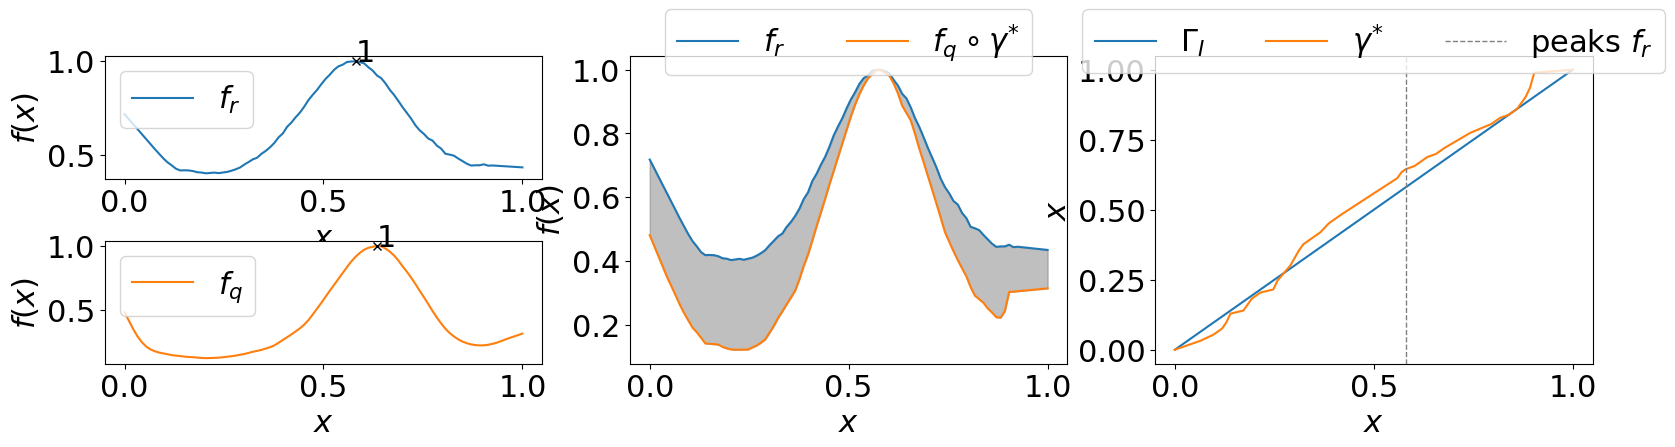

In [17]:
compare_pair(9, 38)

In [18]:
def plot_aligned_sim_to_expt(expt_id):
    cmap = plt.get_cmap("coolwarm")
    fig, ax = plt.subplots()
    distances = np.zeros(len(sim_saxs_data))
    for sim_id in range(len(sim_saxs_data)):
        x_dense,x_dense_scaled, y_dense_expt, y_dense_sim = get_paired_curves(
            exp_data=exp_saxs_data[expt_id],
            sim_data=sim_saxs_data[sim_id],
            q_range=(0.004, 0.02)
        )
        y_ref = y_dense_expt.copy()
        y_query = y_dense_sim.copy()

        amplitude, phase = numpy_apdist(x_dense_scaled, y_ref, y_query, **OPTIM_KWARGS_APDIST)
        dist = np.abs(amplitude + 1j*phase).item()
        distances[sim_id] = dist
        print(f"Expt ID: {expt_id}, Sim ID: {sim_id}, Distance: {dist:.4f}", end="\r")
    
    norm = colors.Normalize(vmin=min(distances), vmax=max(distances))

    for sim_id, phase in enumerate(distances):
        _,_,_, y_dense_sim = get_paired_curves(
            exp_data=exp_saxs_data[expt_id],
            sim_data=sim_saxs_data[sim_id],
            q_range=(0.004, 0.02)
        )
        ax.plot(x_dense, y_dense_sim, color=cmap(norm(phase)), alpha=0.5)
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Distance')
    ax.plot(x_dense, y_ref, color="k", lw=2.0, label=f"Experiment ID: {expt_id}")
    apply_saxs_axis_format(ax)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25))
    plt.show()

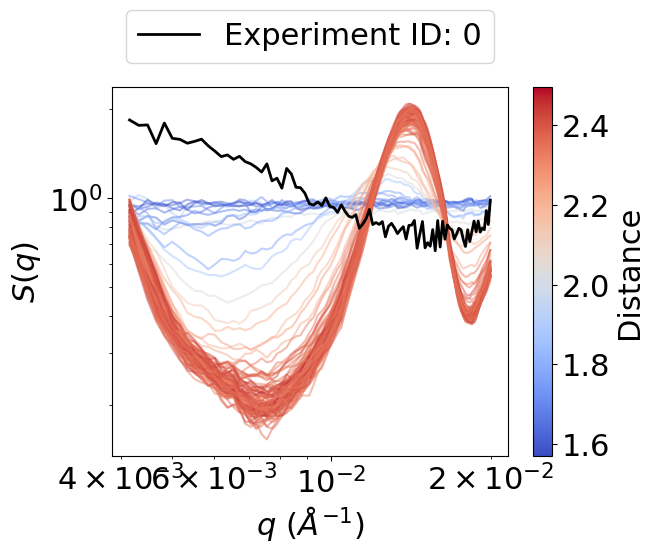

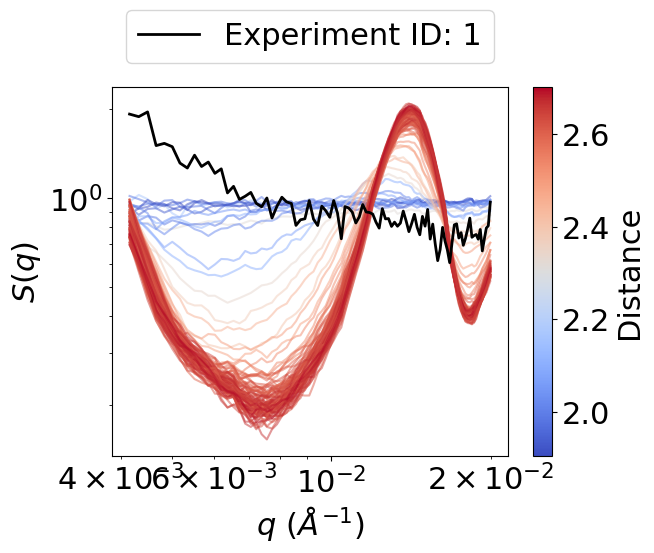

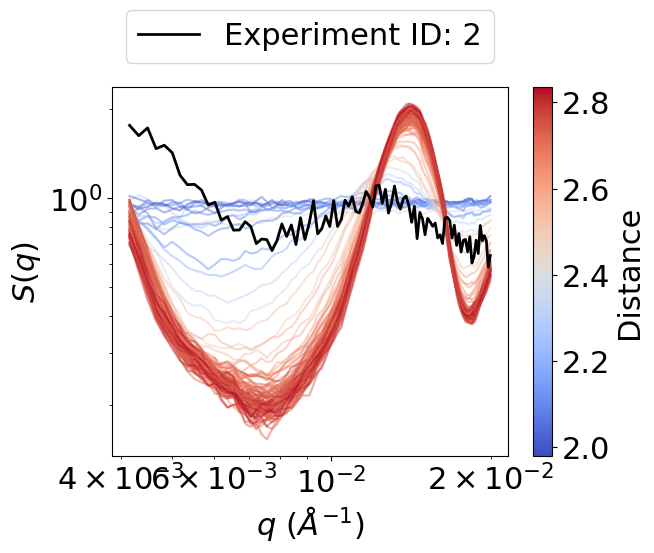

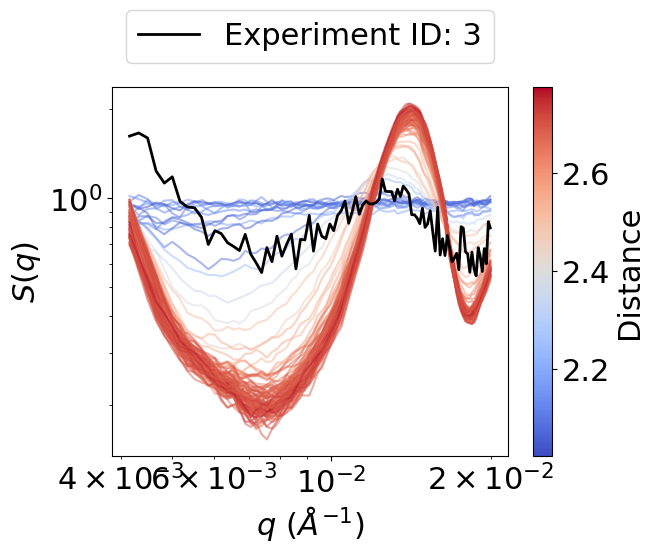

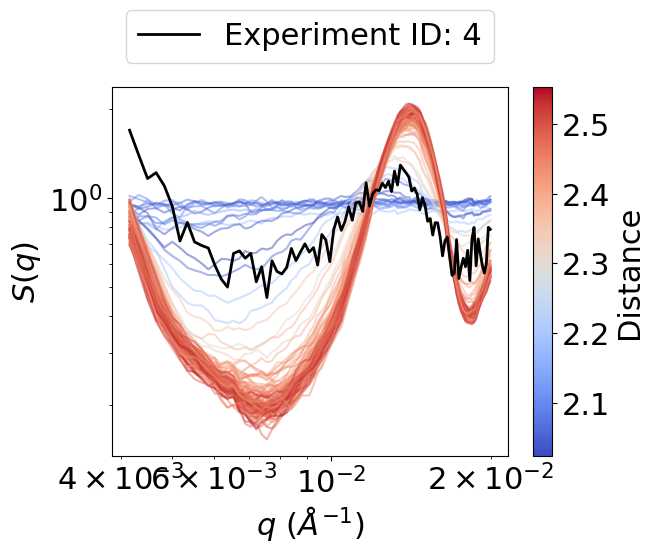

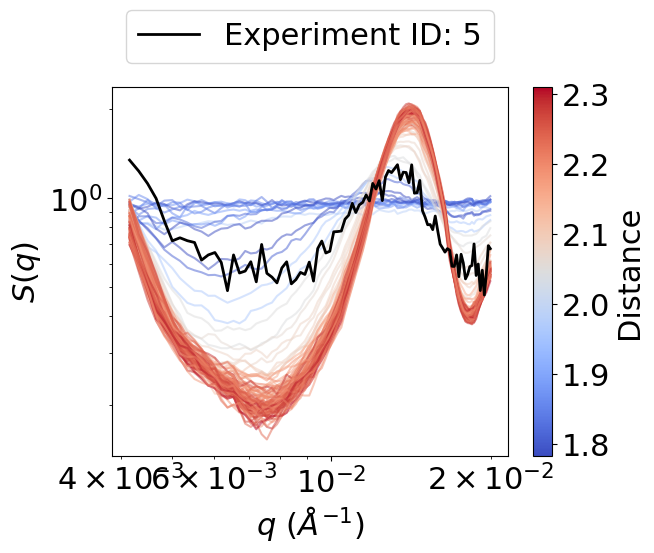

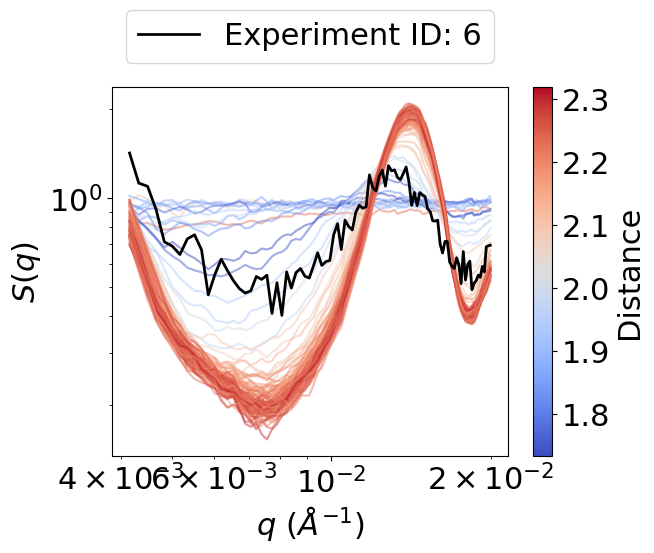

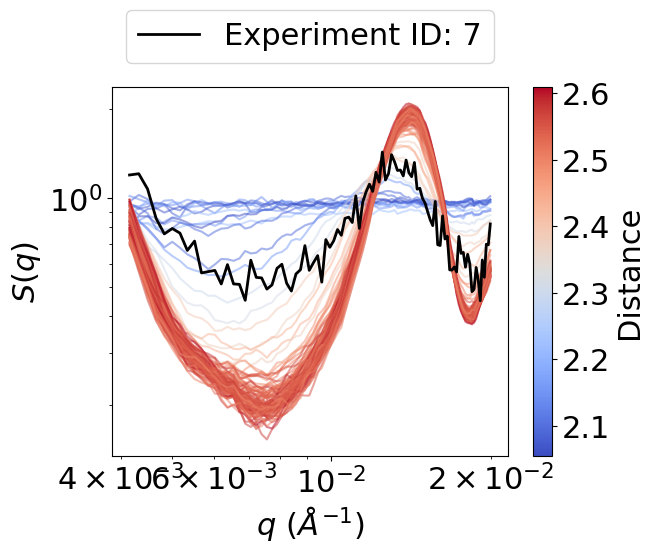

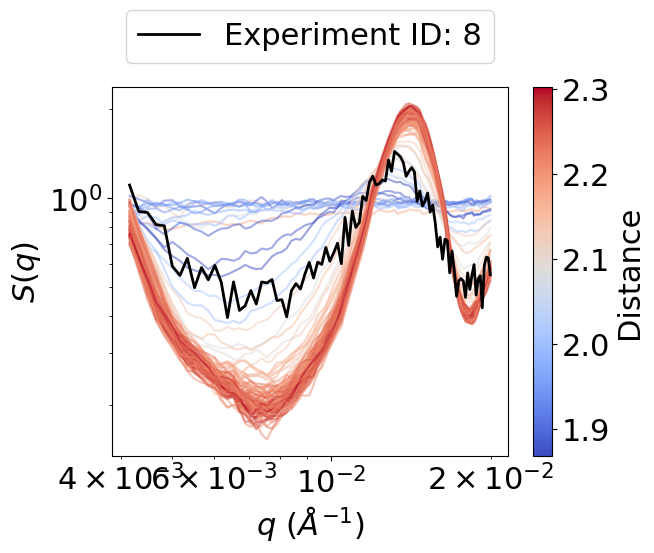

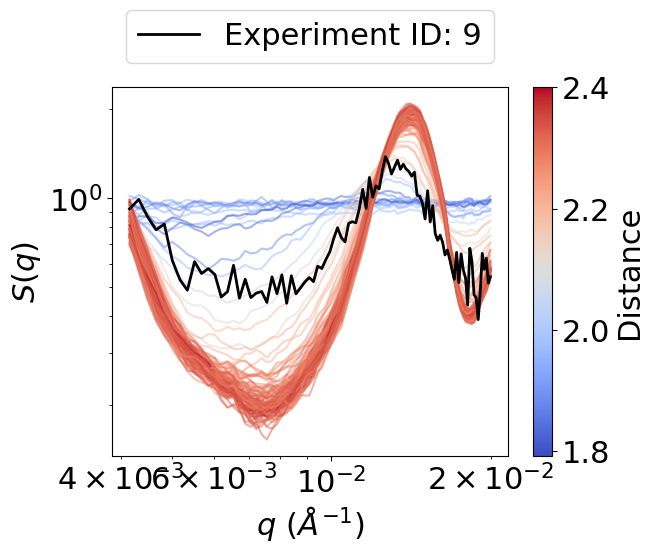

In [19]:
for expt_id in range(len(exp_saxs_data)):
    plot_aligned_sim_to_expt(expt_id)

## Compute and Plot Distance Matrices
Restore the downstream distance-matrix, alignment, and comparison plotting pipeline.

In [20]:
def shape_distance_saxs_numpy(expt_id, sim_id):
    _, x_dense_scaled, y_dense_expt, y_dense_sim = get_paired_curves(
        exp_data=exp_saxs_data[expt_id],
        sim_data=sim_saxs_data[sim_id],
        q_range=(0.004, 0.02)
    )

    y_ref = y_dense_expt.copy()
    y_query = y_dense_sim.copy()
    amplitude, phase = numpy_apdist(x_dense_scaled, y_ref, y_query, **OPTIM_KWARGS_APDIST)
    return np.abs(amplitude + 1j*phase).item()

def create_distance_matrix(exp_data, sim_data):
    score_matrix = np.zeros((len(exp_data), len(sim_data)))

    for expt_id in range(len(exp_data)):
        for sim_id in range(len(sim_data)):
            start = time.time()
            dist = shape_distance_saxs_numpy(expt_id, sim_id)
            score_matrix[expt_id, sim_id] = dist
            end = time.time()
            print(f"Distance between exp {expt_id} and sim {sim_id}: {dist:.4f} (Time: {end - start:.4f}s)")

    return score_matrix

score_matrix_apdist = create_distance_matrix(exp_saxs_data, sim_saxs_data)

Distance between exp 0 and sim 0: 1.9030 (Time: 0.0979s)
Distance between exp 0 and sim 1: 1.7321 (Time: 0.0919s)
Distance between exp 0 and sim 2: 1.6465 (Time: 0.0802s)
Distance between exp 0 and sim 3: 1.5695 (Time: 0.0945s)
Distance between exp 0 and sim 4: 1.6227 (Time: 0.0903s)
Distance between exp 0 and sim 5: 1.6649 (Time: 0.0850s)
Distance between exp 0 and sim 6: 1.9948 (Time: 0.0900s)
Distance between exp 0 and sim 7: 1.6924 (Time: 0.0848s)
Distance between exp 0 and sim 8: 1.6500 (Time: 0.0848s)
Distance between exp 0 and sim 9: 1.8478 (Time: 0.0900s)
Distance between exp 0 and sim 10: 1.7729 (Time: 0.0823s)
Distance between exp 0 and sim 11: 1.7794 (Time: 0.0908s)
Distance between exp 0 and sim 12: 1.8777 (Time: 0.0900s)
Distance between exp 0 and sim 13: 2.0402 (Time: 0.0905s)
Distance between exp 0 and sim 14: 2.1145 (Time: 0.0768s)
Distance between exp 0 and sim 15: 2.1964 (Time: 0.0985s)
Distance between exp 0 and sim 16: 2.1768 (Time: 0.0889s)
Distance between exp 0 a

Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=8.609e-01, max=1.026e+00
Shape of experimental intensities: (94, 1), Shape of simulated intensities: (94, 1)
Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=8.904e-01, max=1.018e+00
Shape of experimental intensities: (94, 1), Shape of simulated intensities: (94, 1)
Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=9.373e-01, max=9.951e-01
Shape of experimental intensities: (94, 1), Shape of simulated intensities: (94, 1)
Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=8.847e-01

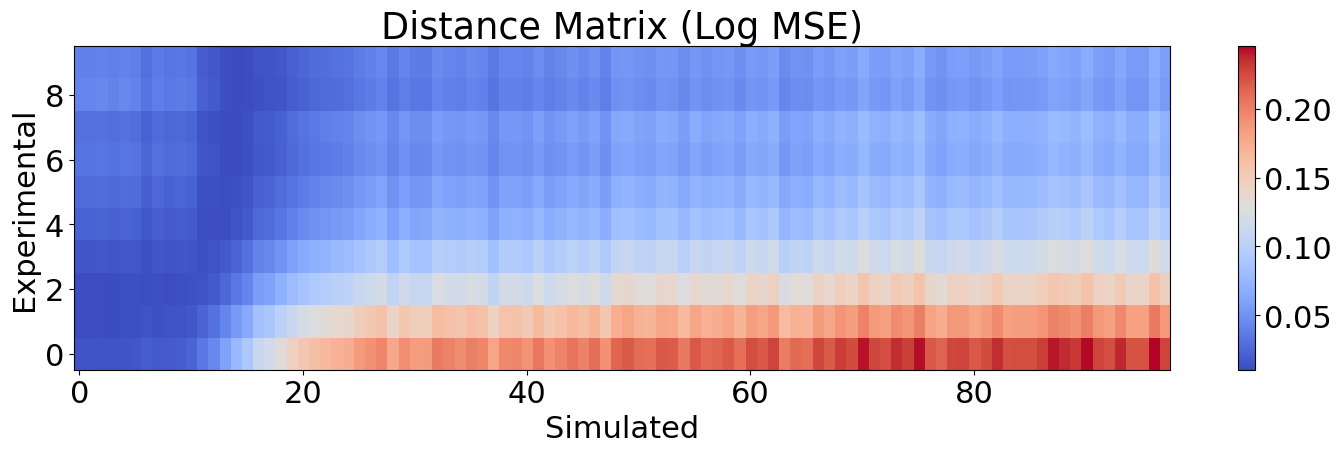

In [21]:
score_matrix_MSE = series_alignment.create_distance_matrix(
    exp_saxs_data, 
    sim_saxs_data, 
    'log_mse', 
    q_range=(0.004, 0.02)
)

fig, ax = plt.subplots(figsize=(15,5))
img = ax.imshow(score_matrix_MSE, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xlabel('Simulated')
ax.set_ylabel('Experimental')
ax.set_title('Distance Matrix (Log MSE)')
plt.colorbar(img, ax=ax)
plt.tight_layout()

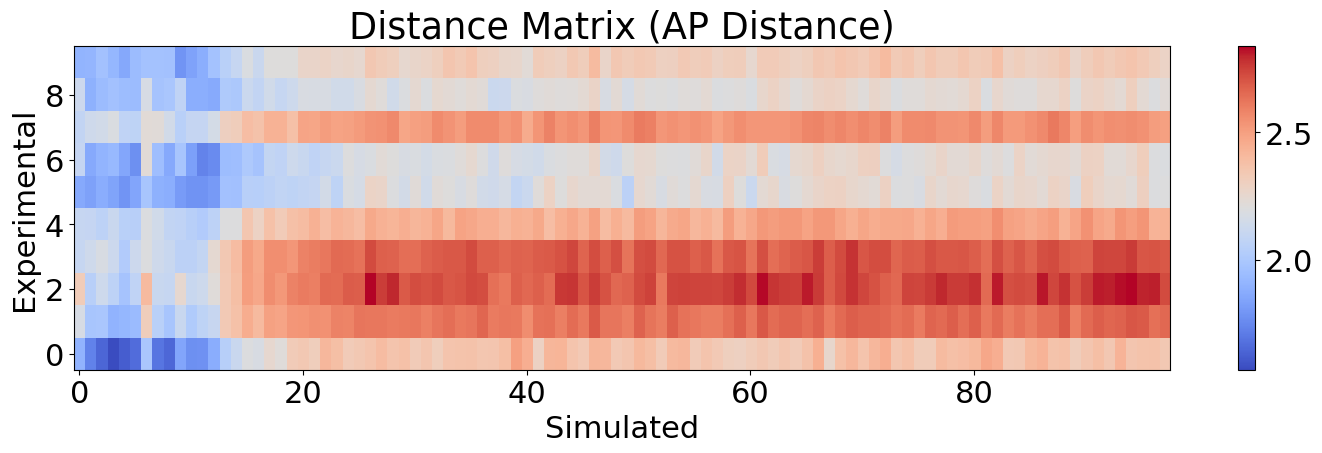

In [22]:
fig, ax = plt.subplots(figsize=(15,5))
img = ax.imshow(score_matrix_apdist, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xlabel('Simulated')
ax.set_ylabel('Experimental')
ax.set_title('Distance Matrix (AP Distance)')
plt.colorbar(img, ax=ax)
plt.tight_layout()

idx_cols_MSE, total_dist_MSE = series_alignment.align_monotone_min(score_matrix_MSE)
idx_cols_apdist, total_dist_apdist = series_alignment.align_monotone_min(score_matrix_apdist)

## Compare Curves by Plotting

NameError: name 'get_curves' is not defined

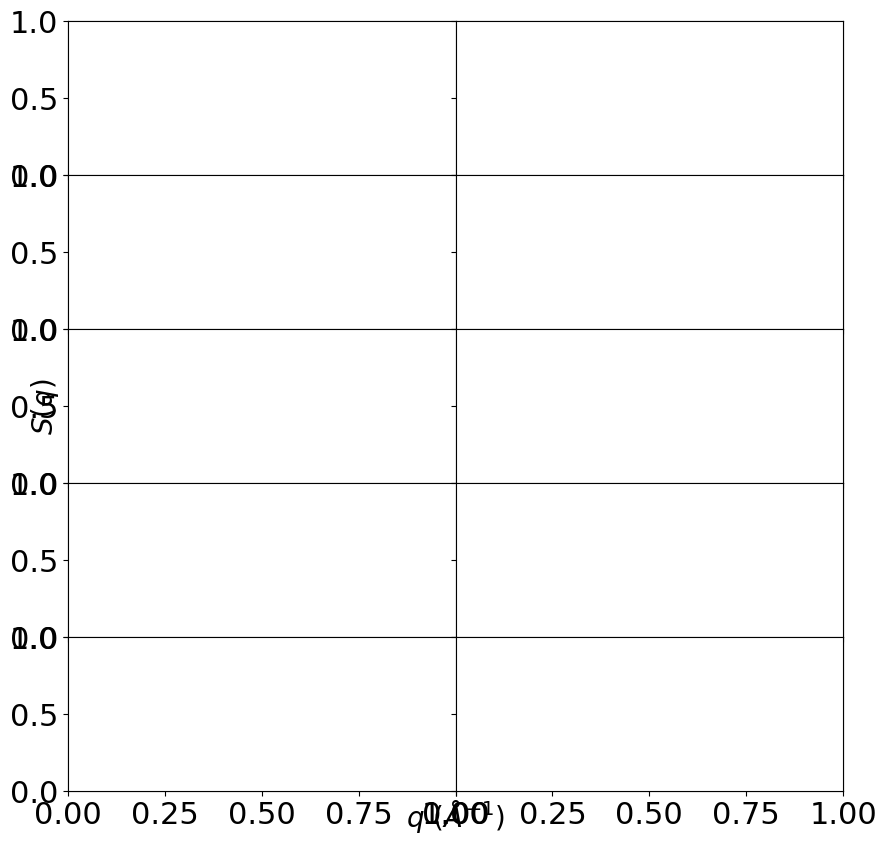

In [23]:
def plot_compared_curves_grid(exp_data, idx_sim):
    norm = colors.Normalize(vmin=0, vmax=100)
    cmap = cm.jet
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    times = np.linspace(0, 100, len(exp_data))

    fig, ax = plt.subplots(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])
    ylabel, xlabel = get_saxs_axis_labels()
    plt.ylabel(ylabel, labelpad=5, fontsize=20)
    plt.xlabel(xlabel, labelpad=5, fontsize=20)

    gs = fig.add_gridspec(5, 2, hspace=0, wspace=0)
    axs = gs.subplots(sharex='col', sharey='row')
    axs = axs.flatten()

    for expt_id in range(len(exp_data)):
        ax = axs[expt_id]
        ax.tick_params(axis="x", which="both", labelbottom=False)

        matched_sim_id = idx_sim[expt_id].item() if isinstance(idx_sim[expt_id], np.int64) else idx_sim[expt_id]
        x_dense, x_dense_scaled, y_dense_expt, y_dense_sim = get_curves(expt_id, matched_sim_id)

        ax.scatter(x_dense, y_dense_expt, linewidth=0.5, color=sm.to_rgba(times[expt_id]))
        ax.plot(x_dense, y_dense_sim, linewidth=3, color='k')
        if not USE_LOG10_SAXS:
            ax.set_xscale('log')
            ax.set_yscale('log')
        ax.set_title(f"({expt_id}, {matched_sim_id})", fontsize=15, y=0.8)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_xticklabels([])

    simulated_handle = Line2D([0], [0], color='k', lw=3)

    experimental_handle = (
        Line2D([0], [0], marker='o', linestyle='None', markersize=8,
               markerfacecolor=cmap(0.1), markeredgecolor='none'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=8,
               markerfacecolor=cmap(0.5), markeredgecolor='none'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=8,
               markerfacecolor=cmap(0.9), markeredgecolor='none'),
    )

    fig.legend(
        [simulated_handle, experimental_handle],
        ['Simulated data', 'Experimental data'],
        handler_map={tuple: HandlerTuple(ndivide=None)},
        loc='upper center',
        bbox_to_anchor=(0.5, 0.98),
        ncol=2,
        frameon=False,
        fontsize=16
    )

    cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Experimental Data Time (Mins)')

    plt.tight_layout(rect=[0, 0, 0.9, 0.94])
    plt.show()

plot_compared_curves_grid(exp_saxs_data, idx_cols_MSE)
plot_compared_curves_grid(exp_saxs_data, idx_cols_apdist)

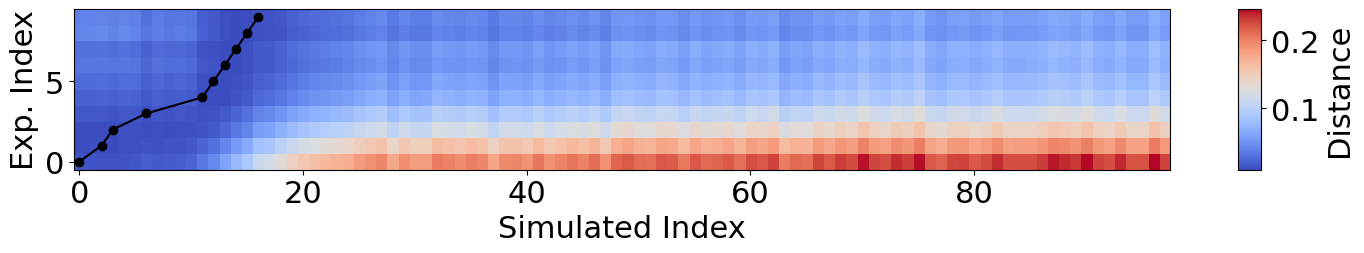

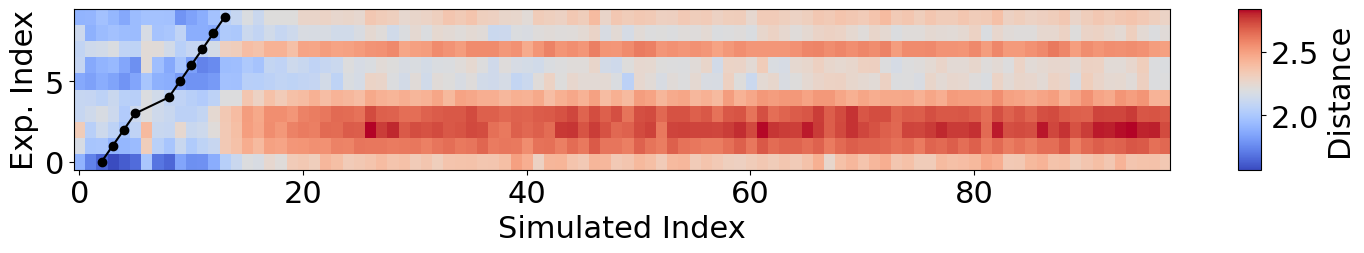

In [24]:
def plot_alignment_with_cost(cost_matrix, idx_cols_min, save_path=None):
    idx_cols_min = np.array(idx_cols_min)
    n_exp, n_sim = cost_matrix.shape
    exp_indices = np.arange(n_exp)

    plt.figure(figsize=(15, 3))
    plt.imshow(cost_matrix, aspect='auto', origin='lower', cmap='coolwarm')
    plt.colorbar(label='Distance', aspect=7)
    plt.plot(idx_cols_min, exp_indices, marker='o', color='k', label='Series Alignment')

    plt.xlabel('Simulated Index')
    plt.ylabel('Exp. Index')
    plt.tight_layout()
    plt.show()

plot_alignment_with_cost(score_matrix_MSE, idx_cols_MSE)
plot_alignment_with_cost(score_matrix_apdist, idx_cols_apdist)

In [25]:
idx_cols_apdist

[np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 13]